# 01 — Chargement et contrôle du jeu BIRD Mini-Dev

Ce notebook décrit les **500 questions déjà préparées** utilisées dans l'étude. Les bases SQLite sont conservées dans `data/raw/bird/dev_databases` et ne sont pas relues ici.

Objectifs : vérifier la qualité du jeu de questions, les bases couvertes et la disponibilité de l'evidence métier.

In [4]:
! pip install  matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 2.0 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.3 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.3 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.3 MB 2.0 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.3 MB 1.7 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.3 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/9.3 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.3 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.3 MB 1.5 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/

In [5]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
QUESTIONS_PATH = ROOT / 'data' / 'processed' / 'questions.json'
with QUESTIONS_PATH.open(encoding='utf-8') as stream:
    questions = json.load(stream)
df = pd.DataFrame(questions)
print(f'{len(df)} questions chargées depuis {QUESTIONS_PATH.relative_to(ROOT)}')
df.head(3)

Matplotlib is building the font cache; this may take a moment.


500 questions chargées depuis data\processed\questions.json


,question_id,db_id,question,evidence,sql_gold,difficulty,schema_ref,metadata
0,bird_mini_1471,debit_card_specializing,What is the ratio of customers who pay in EUR ...,ratio of customers who pay in EUR against cust...,"SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) A...",simple,schemas/debit_card_specializing.json,"{'source': 'BIRD-Mini-Dev', 'split': 'dev'}"
1,bird_mini_1472,debit_card_specializing,"In 2012, who had the least consumption in LAM?",Year 2012 can be presented as Between 201201 A...,SELECT T1.CustomerID FROM customers AS T1 INNE...,moderate,schemas/debit_card_specializing.json,"{'source': 'BIRD-Mini-Dev', 'split': 'dev'}"
2,bird_mini_1473,debit_card_specializing,What was the average monthly consumption of cu...,Average Monthly consumption = AVG(Consumption)...,SELECT AVG(T2.Consumption) / 12 FROM customers...,moderate,schemas/debit_card_specializing.json,"{'source': 'BIRD-Mini-Dev', 'split': 'dev'}"


In [6]:
required = ['question_id', 'db_id', 'question', 'sql_gold', 'evidence']
assert set(required).issubset(df.columns), f'Colonnes absentes : {set(required) - set(df.columns)}'
quality = pd.Series({
    'questions': len(df),
    'question_id uniques': df.question_id.nunique(),
    'bases distinctes': df.db_id.nunique(),
    'SQL gold vide': int(df.sql_gold.fillna('').str.strip().eq('').sum()),
    'evidence vide': int(df.evidence.fillna('').str.strip().eq('').sum()),
})
quality.to_frame('valeur')

,valeur
questions,500
question_id uniques,498
bases distinctes,11
SQL gold vide,0
evidence vide,2


,nombre de questions
db_id,
formula_1,66
superhero,52
card_games,52
european_football_2,51
thrombosis_prediction,50
codebase_community,49
student_club,48
toxicology,40
financial,32


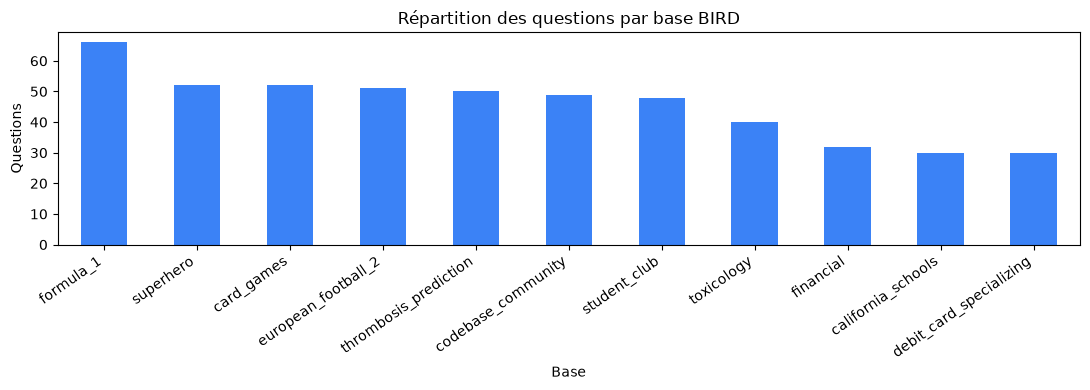

In [7]:
by_database = df.groupby('db_id').size().sort_values(ascending=False)
display(by_database.to_frame('nombre de questions'))
ax = by_database.plot.bar(figsize=(11, 4), color='#3b82f6')
ax.set(title='Répartition des questions par base BIRD', xlabel='Base', ylabel='Questions')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

In [8]:
DB_ROOT = ROOT / 'data' / 'raw' / 'bird' / 'dev_databases'
available = {path.parent.name for path in DB_ROOT.glob('*/*.sqlite')}
expected = set(df.db_id)
pd.DataFrame({
    'bases attendues': sorted(expected),
    'sqlite trouvée': [db_id in available for db_id in sorted(expected)],
})

,bases attendues,sqlite trouvée
0,california_schools,True
1,card_games,True
2,codebase_community,True
3,debit_card_specializing,True
4,european_football_2,True
5,financial,True
6,formula_1,True
7,student_club,True
8,superhero,True
9,thrombosis_prediction,True


## Conclusion

Le jeu d'étude est valide si les 500 identifiants sont uniques, si chaque question possède un SQL de référence et si toutes les bases attendues sont présentes. Les sorties servent directement aux notebooks 02 à 09.